# 🍽️ Analisis Sentimen Berita Online Program MBG
**Algoritma:** Naive Bayes + TF-IDF

**Deskripsi:** Notebook ini mengklasifikasikan sentimen teks berita online tentang Program Makan Bergizi Gratis (MBG) ke dalam tiga kategori: **Positif**, **Negatif**, dan **Netral**.

**Alur Kerja:**
1. Install & Import Library
2. Load Dataset CSV
3. Eksplorasi Data (EDA)
4. Pra-Pemrosesan Teks (Case Folding → Cleansing → Tokenizing → Stopword Removal → Stemming)
5. TF-IDF Vectorization
6. Training Naive Bayes
7. Evaluasi Model (Akurasi, Precision, Recall, F1-Score, Confusion Matrix)
8. Word Cloud per Sentimen
9. Prediksi Teks Baru


## 📦 Cell 1 - Install Library

In [ ]:
!pip install PySastrawi nltk scikit-learn pandas numpy matplotlib seaborn wordcloud
import nltk
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("punkt_tab")
print("✅ Semua library berhasil diinstall")

✅ Semua library berhasil diinstall


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 📚 Cell 2 - Import Library

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

print("✅ Semua library berhasil diimport")

✅ Semua library berhasil diimport


## 📂 Cell 3 - Load Dataset
> Upload file `dataset_mbg_berita_online_v2.csv` ke Google Colab terlebih dahulu

In [ ]:
# Upload file CSV ke Colab
from google.colab import files
uploaded = files.upload()

import io
df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]), encoding="utf-8-sig")

print(f"✅ Dataset berhasil dimuat")
print(f"📊 Jumlah data: {len(df)} baris")
print(f"\nDistribusi Sentimen:")
print(df["sentimen"].value_counts())
df.head()

Saving dataset_mbg_400.csv to dataset_mbg_400.csv
✅ Dataset berhasil dimuat
📊 Jumlah data: 400 baris

Distribusi Sentimen:
sentimen
Positif    181
Negatif    120
Netral      99
Name: count, dtype: int64


,no,teks_asli,sumber,tanggal,url,sentimen
0,1,Badan Gizi Nasional (BGN) memastikan peningkat...,Antara News,2026-07-13,https://www.antaranews.com/berita/5647909/mbg-...,Positif
1,2,Wakil Kepala BGN Trenggono meninjau pelaksanaa...,Antara News,2026-07-13,https://www.antaranews.com/berita/5647909/mbg-...,Positif
2,3,BGN mengingatkan bahwa kualitas gizi tetap men...,Antara News,2026-07-13,https://www.antaranews.com/berita/5647909/mbg-...,Positif
3,4,Menu harian MBG perlu mengandung protein hewan...,Antara News,2026-07-13,https://www.antaranews.com/berita/5647909/mbg-...,Positif
4,5,Kami ingin memastikan setiap anak memperoleh a...,Antara News,2026-07-13,https://www.antaranews.com/berita/5647909/mbg-...,Positif


## 📊 Cell 4 - Eksplorasi Data (EDA)

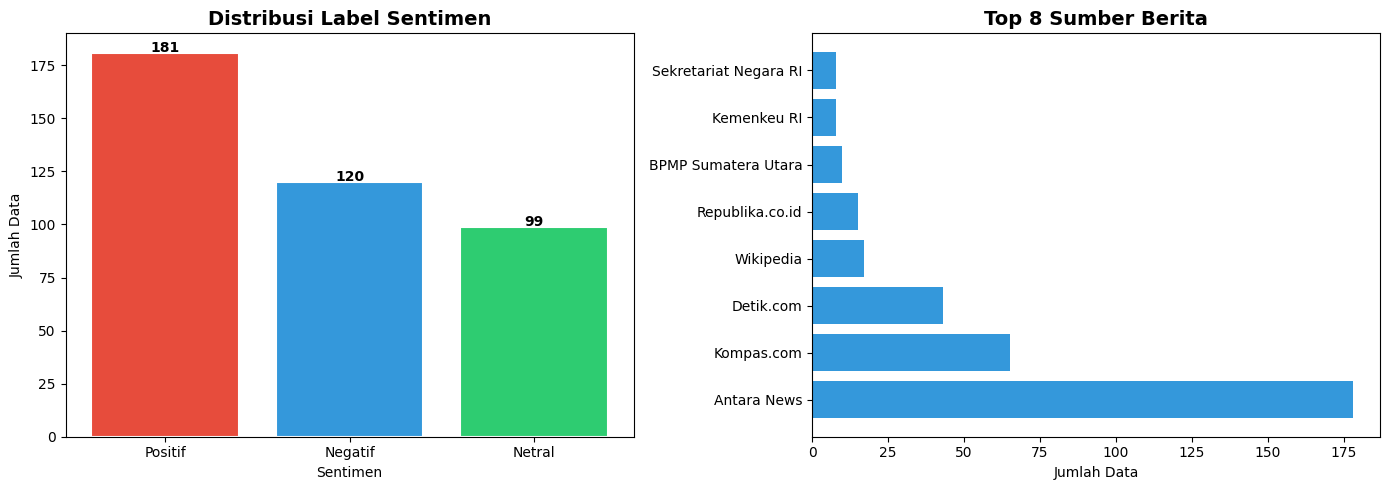

✅ Grafik distribusi tersimpan


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafik distribusi sentimen
sentimen_count = df["sentimen"].value_counts()
colors = ["#e74c3c", "#3498db", "#2ecc71"]
bars = axes[0].bar(sentimen_count.index, sentimen_count.values, color=colors, edgecolor="white", linewidth=1.5)
axes[0].set_title("Distribusi Label Sentimen", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Sentimen"); axes[0].set_ylabel("Jumlah Data")
for bar, v in zip(bars, sentimen_count.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.3, str(v), ha="center", fontweight="bold")

# Grafik sumber berita
top_sumber = df["sumber"].value_counts().head(8)
axes[1].barh(top_sumber.index, top_sumber.values, color="#3498db")
axes[1].set_title("Top 8 Sumber Berita", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Jumlah Data")

plt.tight_layout()
plt.savefig("distribusi_data.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Grafik distribusi tersimpan")

## 🔧 Cell 5 - Pra-Pemrosesan Teks

In [ ]:
# Inisialisasi Sastrawi
factory_stem = StemmerFactory()
stemmer = factory_stem.create_stemmer()

factory_stop = StopWordRemoverFactory()
stopword_sastrawi = set(factory_stop.get_stop_words())
stopword_nltk = set(stopwords.words("indonesian"))

tambahan_stopword = {
    "program","mbg","makan","bergizi","gratis","indonesia","juga","sudah",
    "akan","lebih","yang","untuk","dari","dengan","pada","ini","itu","ke",
    "di","dan","atau","adalah","dalam","oleh","sehingga","bahwa","dapat",
    "telah","sejak","tidak","agar","saat","bagi","hingga","yakni","serta",
    "maupun","namun","tetapi","adapun","yaitu","tersebut","hal","pula"
}
all_stopwords = stopword_sastrawi | stopword_nltk | tambahan_stopword
print(f"Total stopword: {len(all_stopwords)}")

def preprocess(text):
    # 1. Case Folding
    text = str(text).lower()
    # 2. Cleansing
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    # 3. Tokenizing
    tokens = word_tokenize(text)
    # 4. Stopword Removal
    tokens = [t for t in tokens if t not in all_stopwords and len(t) > 2]
    # 5. Stemming
    tokens = [stemmer.stem(t) for t in tokens]
    return " ".join(tokens)

print("⏳ Memproses teks (±2-3 menit untuk stemming)...")
df["teks_bersih"] = df["teks_asli"].apply(preprocess)
print("✅ Pra-pemrosesan selesai!")

print("\nContoh hasil preprocessing:")
for i in range(3):
    print(f"\n[{i+1}] ASLI   : {df['teks_asli'].iloc[i][:80]}...")
    print(f"    BERSIH : {df['teks_bersih'].iloc[i][:80]}...")

Total stopword: 821
⏳ Memproses teks (±2-3 menit untuk stemming)...
✅ Pra-pemrosesan selesai!

Contoh hasil preprocessing:

[1] ASLI   : Badan Gizi Nasional (BGN) memastikan peningkatan kualitas gizi dalam Program Mak...
    BERSIH : badan gizi nasional bgn tingkat kualitas gizi gulir libur sekolah...

[2] ASLI   : Wakil Kepala BGN Trenggono meninjau pelaksanaan Program MBG di beberapa sekolah ...
    BERSIH : wakil kepala bgn trenggono tinjau laksana sekolah sppg wilayah jakarta pusat upa...

[3] ASLI   : BGN mengingatkan bahwa kualitas gizi tetap menjadi prioritas utama dalam setiap ...
    BERSIH : bgn kualitas gizi prioritas utama menu saji terima manfaat...


## 🏷️ Cell 6 - Encode Label Sentimen

In [ ]:
label_map = {"Positif": 2, "Netral": 1, "Negatif": 0}
df["label"] = df["sentimen"].map(label_map)

print("Pemetaan label:")
for k, v in label_map.items():
    print(f"  {k} → {v}")
print(f"\nDistribusi label:\n{df['label'].value_counts().sort_index()}")

Pemetaan label:
  Positif → 2
  Netral → 1
  Negatif → 0

Distribusi label:
label
0    120
1     99
2    181
Name: count, dtype: int64


## ✂️ Cell 7 - Split Data Latih & Uji (80:20)

In [ ]:
X = df["teks_bersih"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Pembagian data selesai")
print(f"📌 Data latih : {len(X_train)} baris ({len(X_train)/len(df)*100:.0f}%)")
print(f"📌 Data uji   : {len(X_test)} baris ({len(X_test)/len(df)*100:.0f}%)")

✅ Pembagian data selesai
📌 Data latih : 320 baris (80%)
📌 Data uji   : 80 baris (20%)


## 🔢 Cell 8 - TF-IDF Vectorization

In [ ]:
tfidf = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1, 2),
    min_df=1,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"✅ TF-IDF selesai")
print(f"📌 Dimensi matriks latih : {X_train_tfidf.shape}")
print(f"📌 Dimensi matriks uji   : {X_test_tfidf.shape}")
print(f"📌 Jumlah fitur vocab    : {len(tfidf.vocabulary_)}")

# Top 20 kata bobot TF-IDF tertinggi
feature_names = tfidf.get_feature_names_out()
tfidf_sum = X_train_tfidf.sum(axis=0).A1
top_idx = tfidf_sum.argsort()[::-1][:20]
print(f"\nTop 20 kata bobot TF-IDF tertinggi:")
for i in top_idx:
    print(f"  {feature_names[i]:<30} {tfidf_sum[i]:.4f}")

✅ TF-IDF selesai
📌 Dimensi matriks latih : (320, 1000)
📌 Dimensi matriks uji   : (80, 1000)
📌 Jumlah fitur vocab    : 1000

Top 20 kata bobot TF-IDF tertinggi:
  anak                           10.7413
  bgn                            10.6867
  gizi                           9.5811
  sppg                           8.3975
  terima                         8.2894
  makan                          7.4284
  manfaat                        7.3986
  sekolah                        7.3397
  anggar                         6.9530
  siswa                          6.8934
  perintah                       6.7383
  terima manfaat                 6.5671
  kelola                         6.0806
  racun                          5.9638
  nasional                       5.9509
  tingkat                        5.9071
  juta                           5.6710
  daerah                         5.5695
  stunting                       5.5691
  presiden                       5.4821


## 🤖 Cell 9 - Training Model Naive Bayes

In [ ]:
model_nb = MultinomialNB(alpha=1.0)  # Laplace Smoothing
model_nb.fit(X_train_tfidf, y_train)

print("✅ Model Naive Bayes berhasil dilatih")
print(f"📌 Metode    : Multinomial Naive Bayes")
print(f"📌 Smoothing : Laplace (alpha=1.0)")
print(f"📌 Kelas     : {model_nb.classes_} → [Negatif, Netral, Positif]")

✅ Model Naive Bayes berhasil dilatih
📌 Metode    : Multinomial Naive Bayes
📌 Smoothing : Laplace (alpha=1.0)
📌 Kelas     : [0 1 2] → [Negatif, Netral, Positif]


## 📈 Cell 10 - Evaluasi Model

In [ ]:
y_pred = model_nb.predict(X_test_tfidf)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
rec  = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1   = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("=" * 50)
print("     HASIL EVALUASI MODEL NAIVE BAYES")
print("=" * 50)
print(f"  Akurasi   : {acc*100:.2f}%")
print(f"  Precision : {prec*100:.2f}%")
print(f"  Recall    : {rec*100:.2f}%")
print(f"  F1-Score  : {f1*100:.2f}%")
print("=" * 50)

label_names = ["Negatif", "Netral", "Positif"]
print("\nLaporan Klasifikasi Per Kelas:")
print(classification_report(y_test, y_pred, target_names=label_names, zero_division=0))

     HASIL EVALUASI MODEL NAIVE BAYES
  Akurasi   : 71.25%
  Precision : 74.83%
  Recall    : 71.25%
  F1-Score  : 67.43%

Laporan Klasifikasi Per Kelas:
              precision    recall  f1-score   support

     Negatif       0.80      0.67      0.73        24
      Netral       0.83      0.25      0.38        20
     Positif       0.67      1.00      0.80        36

    accuracy                           0.71        80
   macro avg       0.77      0.64      0.64        80
weighted avg       0.75      0.71      0.67        80



## 🗂️ Cell 11 - Confusion Matrix

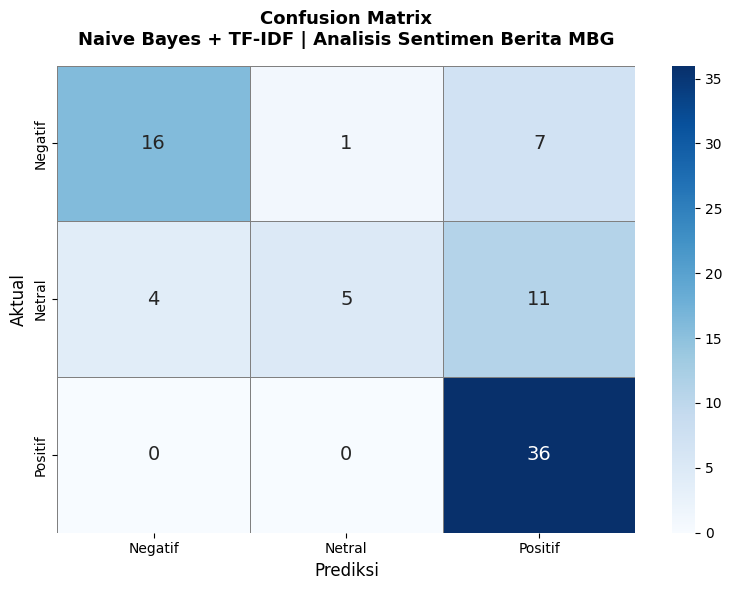

✅ Confusion matrix tersimpan sebagai confusion_matrix.png


In [ ]:
cm = confusion_matrix(y_test, y_pred)
label_names = ["Negatif", "Netral", "Positif"]

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names,
            linewidths=0.5, linecolor="gray", annot_kws={"size": 14})
plt.title("Confusion Matrix\nNaive Bayes + TF-IDF | Analisis Sentimen Berita MBG",
          fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Prediksi", fontsize=12)
plt.ylabel("Aktual", fontsize=12)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Confusion matrix tersimpan sebagai confusion_matrix.png")

## ☁️ Cell 12 - Word Cloud per Sentimen

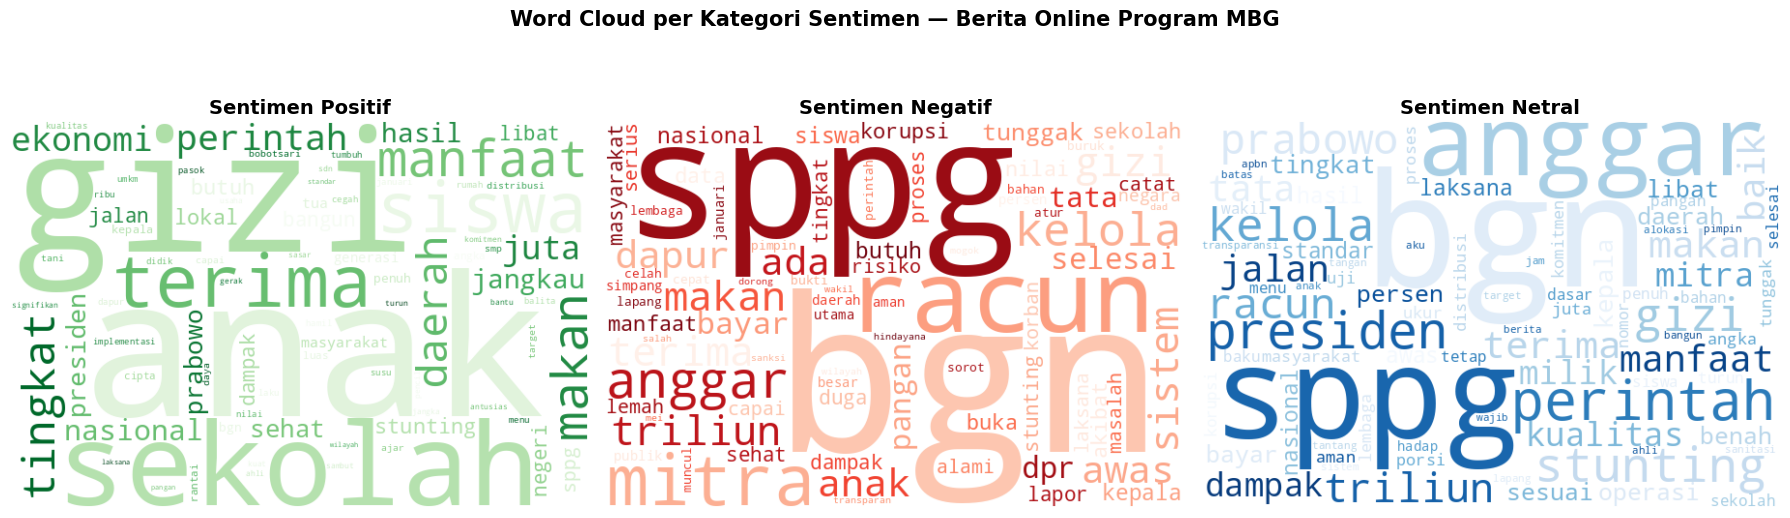

✅ Word cloud tersimpan sebagai wordcloud_sentimen.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
config = {"Positif": "Greens", "Negatif": "Reds", "Netral": "Blues"}

for ax, (label, cmap) in zip(axes, config.items()):
    teks = " ".join(df[df["sentimen"] == label]["teks_bersih"].tolist())
    if teks.strip():
        wc = WordCloud(width=600, height=400, background_color="white",
                       colormap=cmap, max_words=80, collocations=False).generate(teks)
        ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"Sentimen {label}", fontsize=14, fontweight="bold")
    ax.axis("off")

plt.suptitle("Word Cloud per Kategori Sentimen — Berita Online Program MBG",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("wordcloud_sentimen.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Word cloud tersimpan sebagai wordcloud_sentimen.png")

## 🔮 Cell 13 - Prediksi Teks Baru

In [ ]:
def prediksi_sentimen(teks_baru):
    teks_clean = preprocess(teks_baru)
    vec  = tfidf.transform([teks_clean])
    pred = model_nb.predict(vec)[0]
    prob = model_nb.predict_proba(vec)[0]
    label_decode = {2: "✅ Positif", 1: "🔵 Netral", 0: "❌ Negatif"}
    print(f"📰 Teks Input  : {teks_baru[:90]}...")
    print(f"🎯 Prediksi    : {label_decode[pred]}")
    print(f"📊 Probabilitas: Negatif={prob[0]*100:.1f}%  Netral={prob[1]*100:.1f}%  Positif={prob[2]*100:.1f}%")
    print("-" * 70)

print("=" * 70)
print("UJI COBA PREDIKSI TEKS BERITA BARU")
print("=" * 70)
contoh = [
    "Program MBG berhasil meningkatkan angka kehadiran siswa karena anak-anak lebih bersemangat belajar setelah mendapat makanan bergizi.",
    "Ratusan siswa keracunan setelah mengonsumsi makanan dari program MBG, korban langsung dibawa ke puskesmas terdekat untuk mendapat pertolongan.",
    "Pemerintah mengalokasikan Rp335 triliun untuk program MBG pada tahun 2026, meningkat dua kali lipat dibanding tahun sebelumnya."
]
for t in contoh:
    prediksi_sentimen(t)

UJI COBA PREDIKSI TEKS BERITA BARU
📰 Teks Input  : Program MBG berhasil meningkatkan angka kehadiran siswa karena anak-anak lebih bersemangat...
🎯 Prediksi    : ✅ Positif
📊 Probabilitas: Negatif=5.7%  Netral=5.4%  Positif=88.9%
----------------------------------------------------------------------
📰 Teks Input  : Ratusan siswa keracunan setelah mengonsumsi makanan dari program MBG, korban langsung diba...
🎯 Prediksi    : ❌ Negatif
📊 Probabilitas: Negatif=45.3%  Netral=13.1%  Positif=41.6%
----------------------------------------------------------------------
📰 Teks Input  : Pemerintah mengalokasikan Rp335 triliun untuk program MBG pada tahun 2026, meningkat dua k...
🎯 Prediksi    : 🔵 Netral
📊 Probabilitas: Negatif=24.1%  Netral=41.4%  Positif=34.5%
----------------------------------------------------------------------


## 💾 Cell 14 - Simpan Hasil Prediksi ke CSV

In [ ]:
df_result = pd.DataFrame({
    "teks_asli"         : X_test.values,
    "teks_bersih"       : df.loc[X_test.index, "teks_bersih"].values,
    "sentimen_asli"     : df.loc[X_test.index, "sentimen"].values,
    "sentimen_prediksi" : [["Negatif","Netral","Positif"][p] for p in y_pred],
    "benar"             : y_test.values == y_pred
})
df_result.to_csv("hasil_prediksi.csv", index=False, encoding="utf-8-sig")

print(f"✅ Hasil prediksi {len(df_result)} data uji disimpan ke hasil_prediksi.csv")
print("\n" + "=" * 55)
print("       RINGKASAN AKHIR")
print("=" * 55)
print(f"  Total dataset  : {len(df)} baris")
print(f"  Data latih     : {len(X_train)} baris (80%)")
print(f"  Data uji       : {len(X_test)} baris (20%)")
print(f"  Fitur TF-IDF   : {X_train_tfidf.shape[1]}")
print(f"  Akurasi        : {acc*100:.2f}%")
print(f"  Precision      : {prec*100:.2f}%")
print(f"  Recall         : {rec*100:.2f}%")
print(f"  F1-Score       : {f1*100:.2f}%")
print("=" * 55)

# Download semua output
from google.colab import files
files.download("hasil_prediksi.csv")
files.download("confusion_matrix.png")
files.download("wordcloud_sentimen.png")
files.download("distribusi_data.png")

✅ Hasil prediksi 80 data uji disimpan ke hasil_prediksi.csv

       RINGKASAN AKHIR
  Total dataset  : 400 baris
  Data latih     : 320 baris (80%)
  Data uji       : 80 baris (20%)
  Fitur TF-IDF   : 1000
  Akurasi        : 71.25%
  Precision      : 74.83%
  Recall         : 71.25%
  F1-Score       : 67.43%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>